### Model 1: ResNet-18 Acoustic Branch with Quantization-Aware Training

### **Purpose:** Process SPRSound audio data to extract acoustic features and predict respiratory distress symptoms
 
### **Architecture:** ResNet-18 (1D adapted) with Quantization-Aware Training (QAT)

### **Output:** P(y|X_audio) - probability distribution over 6 symptom classes

## 1. Imports

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.quantization import QuantStub, DeQuantStub, prepare_qat, convert
import matplotlib.pyplot as plt
import joblib
import seaborn as sns
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
sys.path.append('..')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create directories
Path("../models").mkdir(exist_ok=True)
Path("../reports/figures").mkdir(parents=True, exist_ok=True)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

Using device: cpu


## 2. Load Prepared Data

In [2]:
# Load features and labels from preparation notebook
X_train = np.load("../../sound_data/model_data/X_train.npy")
X_val = np.load("../../sound_data/model_data/X_val.npy")
X_test = np.load("../../sound_data/model_data/X_test.npy")

y_train_symptom = np.load("../../sound_data/model_data/y_train_symptom.npy", allow_pickle=True)
y_val_symptom = np.load("../../sound_data/model_data/y_val_symptom.npy", allow_pickle=True)
y_test_symptom = np.load("../../sound_data/model_data/y_test_symptom.npy", allow_pickle=True)

print("="*60)
print("SPRSOUND DATA LOADED")
print("="*60)
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"\nTotal samples: {len(X_train) + len(X_val) + len(X_test)}")

SPRSOUND DATA LOADED
X_train shape: (4596, 33)
X_val shape: (985, 33)
X_test shape: (986, 33)

Total samples: 6567


## 3. Label Encoding & Class Distribution

In [3]:
# Encode symptom labels
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train_symptom)
y_val_enc = label_encoder.transform(y_val_symptom)
y_test_enc = label_encoder.transform(y_test_symptom)

print("\n Class Distribution:")
print("-" * 40)
for i, class_name in enumerate(label_encoder.classes_):
    count = np.sum(y_train_enc == i)
    percentage = 100 * count / len(y_train_enc)
    risk = "🔴 HIGH" if class_name in ['stridor', 'wheeze'] else "🟡 MEDIUM" if class_name in ['rhonchi', 'wheeze_crackle'] else "🟢 LOW"
    print(f"  {i}: {class_name:<15} {count:4d} samples ({percentage:5.2f}%) {risk}")

# Compute class weights for imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_enc), y=y_train_enc)
class_weights = torch.FloatTensor(class_weights).to(device)
print(f"\n Class weights: {class_weights.cpu().numpy()}")


 Class Distribution:
----------------------------------------
  0: crackles         759 samples (16.51%) 🟢 LOW
  1: other           3324 samples (72.32%) 🟢 LOW
  2: rhonchi           54 samples ( 1.17%) 🟡 MEDIUM
  3: stridor           21 samples ( 0.46%) 🔴 HIGH
  4: wheeze           384 samples ( 8.36%) 🔴 HIGH
  5: wheeze_crackle    54 samples ( 1.17%) 🟡 MEDIUM

 Class weights: [ 1.0092226   0.23044525 14.185185   36.47619     1.9947916  14.185185  ]


## 4. Define ResNet-18 Model with QAT Support

In [4]:
class ResidualBlock1D(nn.Module):
    # Basic Residual Block for ResNet-18
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, 
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

class ResNet18_1D(nn.Module):
    # ResNet-18 adapted for 1D audio features with QAT support
    def __init__(self, input_dim=33, num_classes=6):
        super().__init__()
        
        # Quantization stubs
        self.quant = QuantStub()
        self.dequant = DeQuantStub()
        
        # Initial convolution
        self.conv1 = nn.Conv1d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        
        # ResNet-18 layers
        self.layer1 = self._make_layer(64, 64, 2, stride=1)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)
        
        # Global pooling and classifier
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512, num_classes)
        
    def _make_layer(self, in_channels, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels),
            )

        layers = []
        layers.append(ResidualBlock1D(in_channels, out_channels, stride, downsample))
        
        for _ in range(1, blocks):
            layers.append(ResidualBlock1D(out_channels, out_channels))

        return nn.Sequential(*layers)
    
    def forward(self, x):
        # Quantize input (for QAT)
        x = self.quant(x)
        
        # Add channel dimension
        x = x.unsqueeze(1)
        
        # Initial layers
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        # ResNet blocks
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        # Pooling and classification
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        
        # Dequantize output
        x = self.dequant(x)
        
        return x
    
    def prepare_for_qat(self):
        # Prepare model for Quantization-Aware Training
        self.qconfig = torch.quantization.get_default_qat_qconfig('fbgemm')
        self = prepare_qat(self, inplace=True)
        
    def convert_to_int8(self):
        # Convert to INT8 quantized model
        self.eval()
        self = convert(self, inplace=True)

## 5. Create Data Loaders

In [5]:
batch_size = 64

train_dataset = TensorDataset(
    torch.FloatTensor(X_train),
    torch.LongTensor(y_train_enc)
)
val_dataset = TensorDataset(
    torch.FloatTensor(X_val),
    torch.LongTensor(y_val_enc)
)
test_dataset = TensorDataset(
    torch.FloatTensor(X_test),
    torch.LongTensor(y_test_enc)
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print(f"Data loaders created")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Data loaders created
Train batches: 72
Val batches: 16
Test batches: 16


## 6. Initialize Model

In [6]:
# Hyperparameters
learning_rate = 0.00001  
weight_decay = 1e-4

model = ResNet18_1D(input_dim=X_train.shape[1], num_classes=len(label_encoder.classes_)).to(device)
print(f"Model initialized")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

Model initialized
Total parameters: 3,846,982


## 7. Training Loop (FP32 Baseline)

In [7]:
# Hyperparameters
batch_size = 64
learning_rate = 0.00001  
weight_decay = 1e-4
n_epochs = 50

# Tracking
train_losses = []
val_accuracies = []
val_epochs = []
best_acc = 0
patience_counter = 0

print("\n Starting training...")
for epoch in range(n_epochs):
    # Training
    model.train()
    epoch_loss = 0
    
    for batch_idx, (data, labels) in enumerate(train_loader):
        data = data.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, labels)
        
        loss.backward()
        
        # Gradient clipping (essential for stability)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # Validation every epoch for better tracking
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    
    with torch.no_grad():
        for data, labels in val_loader:
            data = data.to(device)
            labels = labels.to(device)
            
            outputs = model(data)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
    
    accuracy = 100 * correct / total
    val_accuracies.append(accuracy)
    val_epochs.append(epoch)
    
    # Learning rate scheduling based on validation accuracy
    scheduler.step(accuracy)
    
    # Early stopping check
    if accuracy > best_acc:
        best_acc = accuracy
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), "../models/model_1_resnet.pth")
    else:
        patience_counter += 1
    
    # Print progress
    unique_preds = np.unique(all_preds)
    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch:2d} | Loss: {avg_loss:.4f} | Val Acc: {accuracy:.2f}% | '
          f'LR: {current_lr:.2e} | Classes: {unique_preds}')
    
    # Early stopping
    if patience_counter >= 15:
        print(f"\n Early stopping at epoch {epoch}")
        break

print(f"\n Best validation accuracy: {best_acc:.2f}%")


 Starting training...
Epoch  0 | Loss: 1.8654 | Val Acc: 25.99% | LR: 1.00e-05 | Classes: [0 1 2 4 5]
Epoch  1 | Loss: 1.6291 | Val Acc: 22.34% | LR: 1.00e-05 | Classes: [0 1 2 3 4 5]
Epoch  2 | Loss: 1.4852 | Val Acc: 26.09% | LR: 1.00e-05 | Classes: [0 1 2 3 4 5]
Epoch  3 | Loss: 1.3470 | Val Acc: 26.90% | LR: 1.00e-05 | Classes: [0 1 2 3 4 5]
Epoch  4 | Loss: 1.2092 | Val Acc: 30.86% | LR: 1.00e-05 | Classes: [0 1 2 3 4 5]
Epoch  5 | Loss: 1.0773 | Val Acc: 29.04% | LR: 1.00e-05 | Classes: [0 1 2 3 4 5]
Epoch  6 | Loss: 0.9747 | Val Acc: 33.40% | LR: 1.00e-05 | Classes: [0 1 2 3 4 5]
Epoch  7 | Loss: 0.8600 | Val Acc: 29.64% | LR: 1.00e-05 | Classes: [0 1 2 3 4 5]
Epoch  8 | Loss: 0.7878 | Val Acc: 33.81% | LR: 1.00e-05 | Classes: [0 1 2 3 4 5]
Epoch  9 | Loss: 0.6677 | Val Acc: 34.11% | LR: 1.00e-05 | Classes: [0 1 2 3 4 5]
Epoch 10 | Loss: 0.6279 | Val Acc: 35.43% | LR: 1.00e-05 | Classes: [0 1 2 3 4 5]
Epoch 11 | Loss: 0.5500 | Val Acc: 37.66% | LR: 1.00e-05 | Classes: [0 1 2 3 

## 8. Plot Training Progress

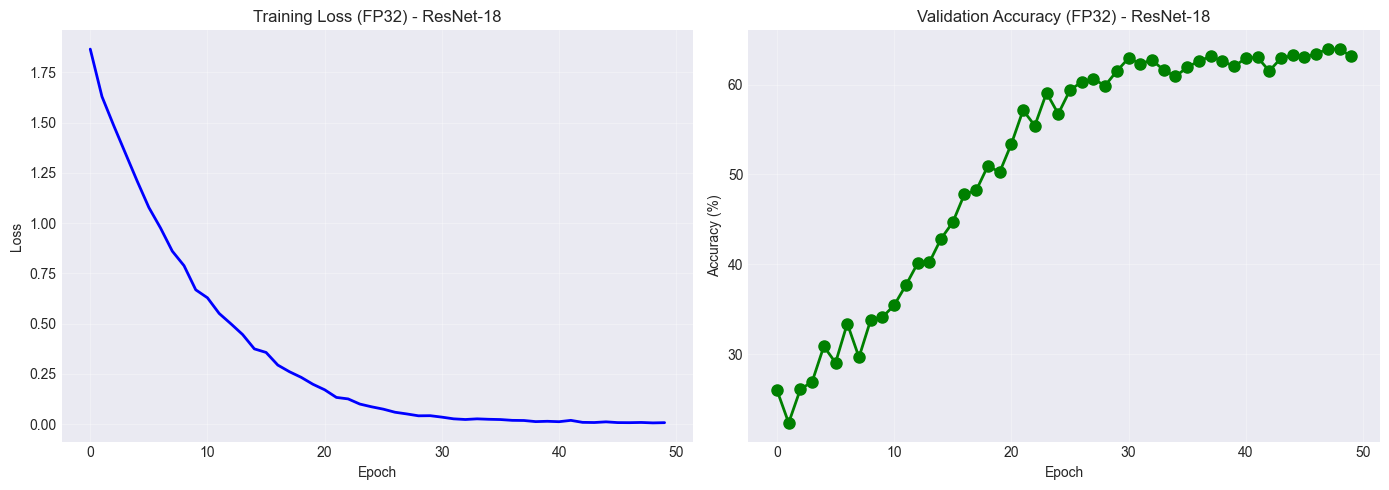


 Best validation accuracy: 63.96% at epoch 47
FP32 model saved


In [8]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, linewidth=2, color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss (FP32) - ResNet-18')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(val_epochs, val_accuracies, 'o-', linewidth=2, color='green', markersize=8)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy (FP32) - ResNet-18')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../reports/figures/model_1_fp32_training.png', dpi=150)
plt.show()

best_val_acc = max(val_accuracies)
best_epoch = val_epochs[np.argmax(val_accuracies)]
print(f"\n Best validation accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")

# Save FP32 model
torch.save(model.state_dict(), "../models/model_1_resnet18_fp32.pth")
print("FP32 model saved")

## 9. Quantization-Aware Training (QAT)

In [9]:
print("\n" + "="*60)
print("QUANTIZATION-AWARE TRAINING (50 EPOCHS)")
print("="*60)

# Create a new model for QAT
qat_model = ResNet18_1D(input_dim=X_train.shape[1], num_classes=len(label_encoder.classes_)).to('cpu')
qat_model.load_state_dict(model.state_dict())  # Transfer weights from best FP32 model

# Prepare for QAT
qat_model.prepare_for_qat()
qat_model.train()

# QAT optimizer - can use slightly higher LR for first few epochs then reduce
qat_optimizer = torch.optim.Adam(qat_model.parameters(), lr=0.0001)  # Start with higher LR
qat_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    qat_optimizer, mode='max', factor=0.5, patience=5
)

# Create CPU data loaders
train_loader_cpu = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader_cpu = DataLoader(val_dataset, batch_size=64)

# QAT training loop - FULL FINE-TUNING
qat_epochs = 50
qat_losses = []
qat_accuracies = []
best_qat_acc = 0

print("\n Starting QAT fine-tuning...")
for epoch in range(qat_epochs):
    # Training
    qat_model.train()
    epoch_loss = 0
    
    for data, labels in train_loader_cpu:
        qat_optimizer.zero_grad()
        outputs = qat_model(data)
        loss = criterion(outputs, labels)
        
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(qat_model.parameters(), max_norm=1.0)
        
        qat_optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader_cpu)
    qat_losses.append(avg_loss)
    
    # Validation
    qat_model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, labels in val_loader_cpu:
            outputs = qat_model(data)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    qat_accuracies.append(accuracy)
    
    # Learning rate scheduling
    qat_scheduler.step(accuracy)
    current_lr = qat_optimizer.param_groups[0]['lr']
    
    # Track best model
    if accuracy > best_qat_acc:
        best_qat_acc = accuracy
        torch.save(qat_model.state_dict(), "../models/model_1_qat_best.pth")
        print(f"★ Epoch {epoch:2d} | Loss: {avg_loss:.4f} | Val Acc: {accuracy:.2f}% | LR: {current_lr:.2e} (NEW BEST)")
    else:
        print(f"  Epoch {epoch:2d} | Loss: {avg_loss:.4f} | Val Acc: {accuracy:.2f}% | LR: {current_lr:.2e}")

print(f"\n Best QAT validation accuracy: {best_qat_acc:.2f}%")

# Load best QAT model for conversion
qat_model.load_state_dict(torch.load("../models/model_1_qat_best.pth"))


QUANTIZATION-AWARE TRAINING (50 EPOCHS)

 Starting QAT fine-tuning...
★ Epoch  0 | Loss: 0.2158 | Val Acc: 33.81% | LR: 1.00e-04 (NEW BEST)
★ Epoch  1 | Loss: 0.2998 | Val Acc: 41.42% | LR: 1.00e-04 (NEW BEST)
  Epoch  2 | Loss: 0.2741 | Val Acc: 41.22% | LR: 1.00e-04
★ Epoch  3 | Loss: 0.2704 | Val Acc: 46.09% | LR: 1.00e-04 (NEW BEST)
★ Epoch  4 | Loss: 0.1765 | Val Acc: 46.50% | LR: 1.00e-04 (NEW BEST)
★ Epoch  5 | Loss: 0.1769 | Val Acc: 54.82% | LR: 1.00e-04 (NEW BEST)
★ Epoch  6 | Loss: 0.1358 | Val Acc: 56.24% | LR: 1.00e-04 (NEW BEST)
  Epoch  7 | Loss: 0.1285 | Val Acc: 40.10% | LR: 1.00e-04
★ Epoch  8 | Loss: 0.1267 | Val Acc: 61.22% | LR: 1.00e-04 (NEW BEST)
  Epoch  9 | Loss: 0.1175 | Val Acc: 60.51% | LR: 1.00e-04
  Epoch 10 | Loss: 0.1005 | Val Acc: 57.56% | LR: 1.00e-04
  Epoch 11 | Loss: 0.0977 | Val Acc: 57.56% | LR: 1.00e-04
  Epoch 12 | Loss: 0.1135 | Val Acc: 56.55% | LR: 1.00e-04
  Epoch 13 | Loss: 0.0866 | Val Acc: 60.20% | LR: 1.00e-04
  Epoch 14 | Loss: 0.0751 

<All keys matched successfully>

 ## 10. Convert to INT8

In [10]:
print("\n" + "="*60)
print("CONVERTING TO INT8")
print("="*60)

# Convert to INT8
qat_model.eval()
qat_model = convert(qat_model, inplace=True)

# Save INT8 model
torch.save(qat_model.state_dict(), "../models/model_1_resnet18_int8.pth")
print("INT8 model saved to: models/model_1_resnet18_int8.pth")

# Model size comparison
import os
fp32_size = os.path.getsize("../models/model_1_resnet18_fp32.pth") / (1024*1024)
int8_size = os.path.getsize("../models/model_1_resnet18_int8.pth") / (1024*1024)

print(f"\n Model Size Comparison:")
print(f"   FP32: {fp32_size:.2f} MB")
print(f"   INT8: {int8_size:.2f} MB")
print(f"   Reduction: {(1 - int8_size/fp32_size)*100:.1f}%")


CONVERTING TO INT8
INT8 model saved to: models/model_1_resnet18_int8.pth

 Model Size Comparison:
   FP32: 14.75 MB
   INT8: 3.87 MB
   Reduction: 73.8%


## 11. Test Set Evaluation (using FP32)

In [19]:
print("\n" + "="*60)
print("TEST SET EVALUATION (FP32)")
print("="*60)

# Load the best FP32 model instead
best_model = ResNet18_1D(input_dim=X_train.shape[1], num_classes=len(label_encoder.classes_)).to(device)
best_model.load_state_dict(torch.load("../models/model_1_resnet18_fp32.pth"))
best_model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for data, labels in test_loader:
        data = data.to(device)
        labels = labels.to(device)
        
        outputs = best_model(data)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Calculate accuracy
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"\n Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Classification report
print("\n Classification Report:")
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))


TEST SET EVALUATION (FP32)

 Test Accuracy: 0.6471 (64.71%)

 Classification Report:
                precision    recall  f1-score   support

      crackles       0.10      0.07      0.08       143
         other       0.75      0.85      0.80       736
       rhonchi       0.00      0.00      0.00        12
       stridor       0.00      0.00      0.00         2
        wheeze       0.08      0.04      0.05        85
wheeze_crackle       0.00      0.00      0.00         8

      accuracy                           0.65       986
     macro avg       0.15      0.16      0.15       986
  weighted avg       0.58      0.65      0.61       986



 ## 12. Save Predictions for Fusion

In [20]:
# Save predictions
np.save("../../sound_data/model_data/model_1_test_predictions.npy", all_preds)
np.save("../../sound_data/model_data/model_1_test_probabilities.npy", all_probs)
np.save("../../sound_data/model_data/model_1_test_labels.npy", all_labels)

print("\n" + "="*60)
print(" PREDICTIONS SAVED FOR FUSION")
print("="*60)
print(f"   - Predictions shape: {all_preds.shape}")
print(f"   - Probabilities shape: {all_probs.shape}")
print(f"   - Labels shape: {all_labels.shape}")
print(f"   Location: ../../sound_data/model_data/")


 PREDICTIONS SAVED FOR FUSION
   - Predictions shape: (986,)
   - Probabilities shape: (986, 6)
   - Labels shape: (986,)
   Location: ../../sound_data/model_data/


## 13. Save Audio Labels for Fusion

In [24]:
# Save audio test labels (these are from your test set)
if 'all_labels' in locals() and all_labels is not None:
    np.save("../../sound_data/model_data/audio_test_labels.npy", all_labels)
    print(f"Audio labels saved: {all_labels.shape}")
    print(f"Class distribution: 0: {np.sum(all_labels==0)}, 1: {np.sum(all_labels==1)}")
else:
    print("all_labels not found. Please check your test evaluation cell.")

Audio labels saved: (986,)
Class distribution: 0: 143, 1: 736


## 14. Export for Deployment

In [21]:
# Save the quantized model directly
torch.save(qat_model.state_dict(), "../models/model_1_resnet18_int8.pth")
print(" Model saved as PyTorch state dict")

# For mobile deployment, use torch.jit.script
scripted_model = torch.jit.script(qat_model)
scripted_model.save("../models/model_1_resnet18_int8.pt")
print(" TorchScript model saved for mobile deployment")

# Optimize for mobile
from torch.utils.mobile_optimizer import optimize_for_mobile
optimized_model = optimize_for_mobile(scripted_model)
optimized_model._save_for_lite_interpreter("../models/model_1_resnet18_int8.ptl")
print(" Lite interpreter model saved for Android/iOS")

 Model saved as PyTorch state dict
 TorchScript model saved for mobile deployment
 Lite interpreter model saved for Android/iOS
